In [1]:
import pandas
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.impute import SimpleImputer
from matplotlib.colors import LogNorm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_curve, auc, precision_score, recall_score, f1_score, precision_recall_fscore_support, ConfusionMatrixDisplay

In [2]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_caract = []

for year in years:
    df_caract_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"caract-{year}.csv"), encoding="utf-8", sep = ";")
    df_caract.append(df_caract_year)

df_caract = pandas.concat(df_caract)
df_caract.head()

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,201900000001,30,11,2019,01:30,4,93,93053,1,1,1,2,AUTOROUTE A3,"48,8962100","2,4701200"
1,201900000002,30,11,2019,02:50,3,93,93066,1,1,1,6,AUTOROUTE A1,"48,9307000","2,3688000"
2,201900000003,28,11,2019,15:15,1,92,92036,1,1,1,4,AUTOROUTE A86,"48,9358718","2,3191744"
3,201900000004,30,11,2019,20:20,5,94,94069,1,1,1,4,A4,"48,8173295","2,4281502"
4,201900000005,30,11,2019,04:00,3,94,94028,1,1,1,2,A86 INT,"48,7763620","2,4332540"


In [3]:
df_caract.columns

Index(['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg',
       'int', 'atm', 'col', 'adr', 'lat', 'long'],
      dtype='str')

In [4]:
df_caract.isna().sum()

Num_Acc       0
jour          0
mois          0
an            0
hrmn          0
lum           0
dep           0
com           0
agg           0
int           0
atm           0
col           0
adr        6289
lat           0
long          0
dtype: int64

In [5]:
# Drop ["adr","dep","com"] as we will work in our analysis with latitude and logitude and they contain this info already
df_caract.drop(columns=["adr","dep","com"],inplace=True)

In [6]:
df_caract.info()

<class 'pandas.DataFrame'>
Index: 327628 entries, 0 to 54401
Data columns (total 12 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   Num_Acc  327628 non-null  int64
 1   jour     327628 non-null  int64
 2   mois     327628 non-null  int64
 3   an       327628 non-null  int64
 4   hrmn     327628 non-null  str  
 5   lum      327628 non-null  int64
 6   agg      327628 non-null  int64
 7   int      327628 non-null  int64
 8   atm      327628 non-null  int64
 9   col      327628 non-null  int64
 10  lat      327628 non-null  str  
 11  long     327628 non-null  str  
dtypes: int64(9), str(3)
memory usage: 32.5 MB


In [7]:
df_caract["lat"] = pandas.to_numeric(
    df_caract["lat"].str.replace(",", "."),
    errors="coerce"
)

df_caract["long"] = pandas.to_numeric(
    df_caract["long"].str.replace(",", "."),
    errors="coerce"
)

In [8]:
df_caract = df_caract.replace(-1, pandas.NA)
df_caract.isna().sum()

Num_Acc       0
jour          0
mois          0
an            0
hrmn          0
lum           9
agg           0
int          14
atm          26
col        1619
lat           0
long          1
dtype: int64

In [9]:
cat_small_na = df_caract.columns[(df_caract.isna().sum() < 5000) & (df_caract.isna().sum() > 0)]
print(cat_small_na)
imputer = SimpleImputer(strategy="most_frequent")


df_caract[cat_small_na] = df_caract[cat_small_na].replace({pandas.NA: np.nan})
df_caract[cat_small_na] = imputer.fit_transform(df_caract[cat_small_na])
df_caract.isna().sum()

Index(['lum', 'int', 'atm', 'col', 'long'], dtype='str')


Num_Acc    0
jour       0
mois       0
an         0
hrmn       0
lum        0
agg        0
int        0
atm        0
col        0
lat        0
long       0
dtype: int64

In [10]:
column_names_to_int = ["jour", "mois", "lum", "agg", "int", "atm", "col"]

df_caract[column_names_to_int] = df_caract[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    )
)

In [11]:
df_caract[["lat", "long"]] = df_caract[["lat", "long"]].astype("float64")

In [12]:
df_caract["lat"].describe()

count    327628.000000
mean         44.343658
std          12.244762
min         -61.425660
25%          44.736676
50%          47.825103
75%          48.860313
max          63.568066
Name: lat, dtype: float64

In [13]:
df_caract["long"].describe()

count    327628.000000
mean          2.171736
std          19.084446
min        -178.158090
25%           1.283565
50%           2.391478
75%           4.795682
max         174.023438
Name: long, dtype: float64

Now we are taking into consideration only accidents that occurred in France

In [14]:
invalid_lat = df_caract[
    (df_caract["lat"] < 41) | (df_caract["lat"] > 51) 
]

len(invalid_lat) / len(df_caract)

0.05513570268719401

In [15]:
invalid_long = df_caract[
    (df_caract["long"] < -5) | (df_caract["long"] > 10)
]

len(invalid_long) / len(df_caract)

0.05454661994701308

In [16]:
df_caract = df_caract[
    (df_caract["lat"].between(41, 51)) &
    (df_caract["long"].between(-5, 10))
]

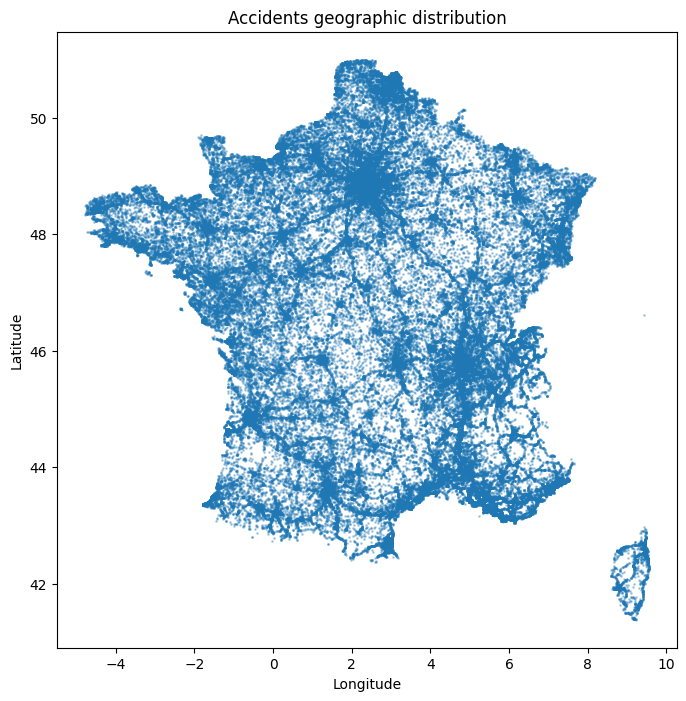

In [17]:
plt.figure(figsize=(8, 8))
plt.scatter(df_caract["long"], df_caract["lat"], s=1, alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accidents geographic distribution")
plt.show()

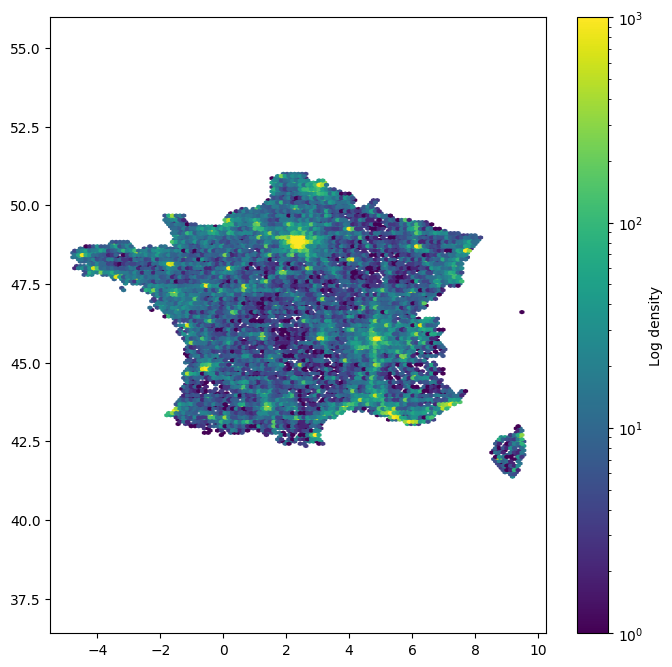

In [18]:
plt.figure(figsize=(8, 8))

hb = plt.hexbin(
    df_caract["long"],
    df_caract["lat"],
    gridsize=120,
    cmap="viridis",
    norm=LogNorm(vmin=1, vmax=1000)
)

plt.colorbar(hb, label="Log density")
plt.axis("equal")
plt.show()

In [19]:
# We need to load usagers, because it conatains our target column
df_usagers = pandas.read_csv("df_usagers_clean.csv")

df_caract_with_target = df_usagers[['Num_Acc', 'grav_bin']].merge(
    df_caract,
    on='Num_Acc',
    how='left'
)

target = "grav_bin"

In [20]:
df_caract_with_target.isna().sum()

Num_Acc         0
grav_bin        0
jour        42192
mois        42192
an          42192
hrmn        42192
lum         42192
agg         42192
int         42192
atm         42192
col         42192
lat         42192
long        42192
dtype: int64

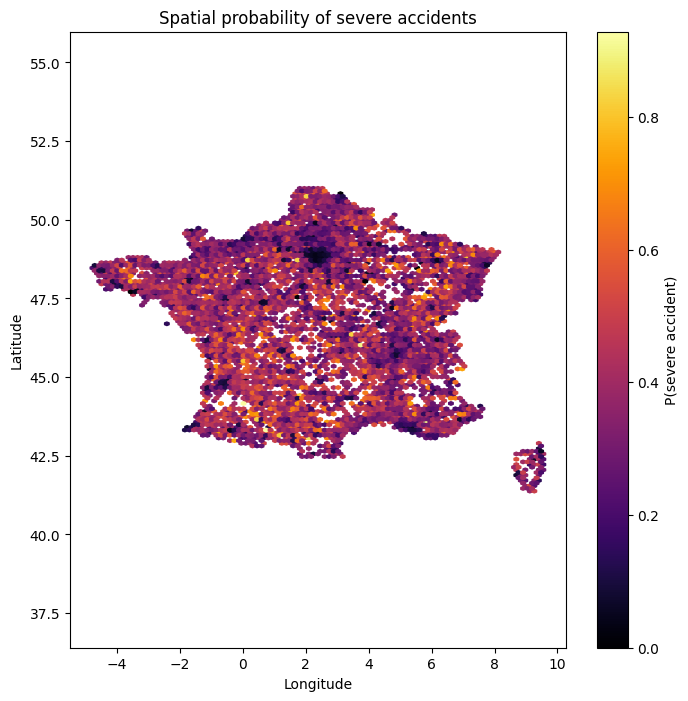

In [21]:
plt.figure(figsize=(8, 8))

hb = plt.hexbin(
    df_caract_with_target["long"],
    df_caract_with_target["lat"],
    C=df_caract_with_target["grav_bin"],
    reduce_C_function=np.mean, # probability of severe
    gridsize=100,
    cmap="inferno",
    mincnt=10 # ignore low-sample cells
)

plt.colorbar(hb, label="P(severe accident)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial probability of severe accidents")

plt.axis("equal")
plt.show()

Encodage temporel :

In [22]:
df_caract['mois'].describe()

count    309533.000000
mean          6.709769
std           3.357667
min           1.000000
25%           4.000000
50%           7.000000
75%          10.000000
max          12.000000
Name: mois, dtype: float64

In [23]:
df_caract['jour'].describe()

count    309533.000000
mean         15.632488
std           8.731284
min           1.000000
25%           8.000000
50%          16.000000
75%          23.000000
max          31.000000
Name: jour, dtype: float64

In [24]:
df_caract["date"] = pandas.to_datetime(
    dict(year=df_caract["an"],
    month=df_caract["mois"],
    day=df_caract["jour"]),
    errors="coerce"
)

In [25]:
df_caract["day_of_year"] = df_caract["date"].dt.dayofyear
df_caract["weekday"] = df_caract["date"].dt.weekday
df_caract["month"] = df_caract["date"].dt.month
df_caract["year"] = df_caract["date"].dt.year

Cycle annuel (jour dans l'année 365)

In [26]:
df_caract["day_sin"] = np.sin(2 * np.pi * df_caract["day_of_year"] / 365)
df_caract["day_cos"] = np.cos(2 * np.pi * df_caract["day_of_year"] / 365)

Cycle mensuel (12 mois)

In [27]:
df_caract["month_sin"] = np.sin(2 * np.pi * df_caract["month"] / 12)
df_caract["month_cos"] = np.cos(2 * np.pi * df_caract["month"] / 12)

Cycle hebdomadaire (7 jours)

In [28]:
df_caract["weekday_sin"] = np.sin(2 * np.pi * df_caract["weekday"] / 7)
df_caract["weekday_cos"] = np.cos(2 * np.pi * df_caract["weekday"] / 7)

Cycle horaire  (24 heures)

In [29]:
df_caract["hrmn"] = df_caract["hrmn"].astype(str).str.strip()
df_caract["hour"] = df_caract["hrmn"].str[:2].astype(int)

In [30]:
df_caract["hour_sin"] = np.sin(2 * np.pi * df_caract["hour"] / 24)
df_caract["hour_cos"] = np.cos(2 * np.pi * df_caract["hour"] / 24)

In [31]:
df_caract["is_weekend"] = df_caract["weekday"].isin([5, 6]).astype(int)

In [32]:
df_caract.drop(columns=["date", "day_of_year", "weekday","hour"
                        ,"month", "year","hrmn","an","jour","mois"], inplace=True)

In [33]:
df_caract.columns

Index(['Num_Acc', 'lum', 'agg', 'int', 'atm', 'col', 'lat', 'long', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos',
       'hour_sin', 'hour_cos', 'is_weekend'],
      dtype='str')

In [34]:
categorical_features = [
 'lum',
 'agg',
 'int',
 'atm',
 'col'
]
binary_features = ["is_weekend"]     
numerical_features = ['lat', 'long', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos',
       'hour_sin', 'hour_cos'] # binary numerical features is_weekend

features = categorical_features + binary_features + numerical_features

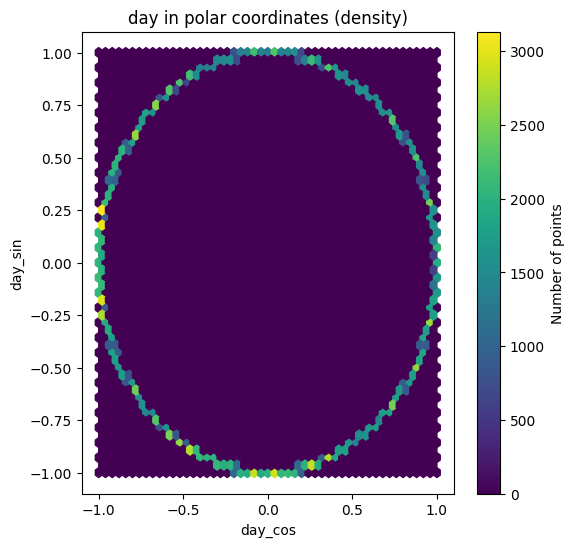

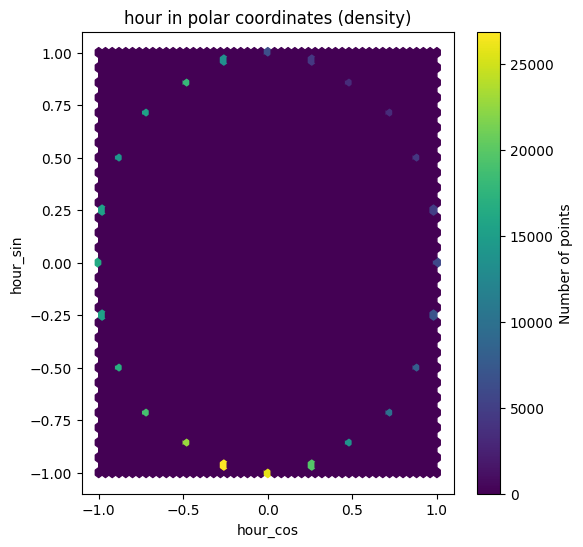

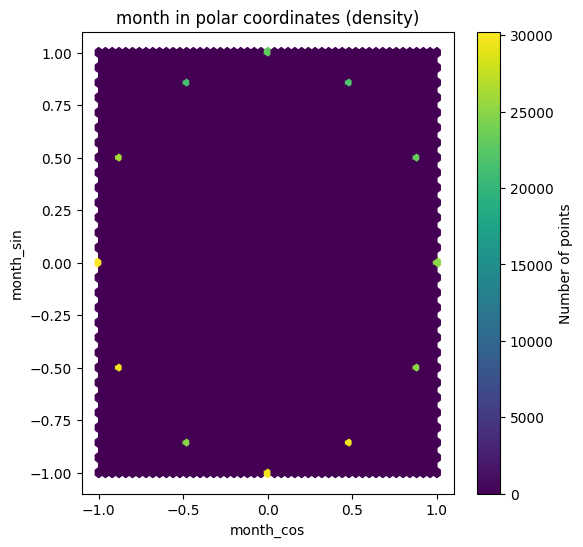

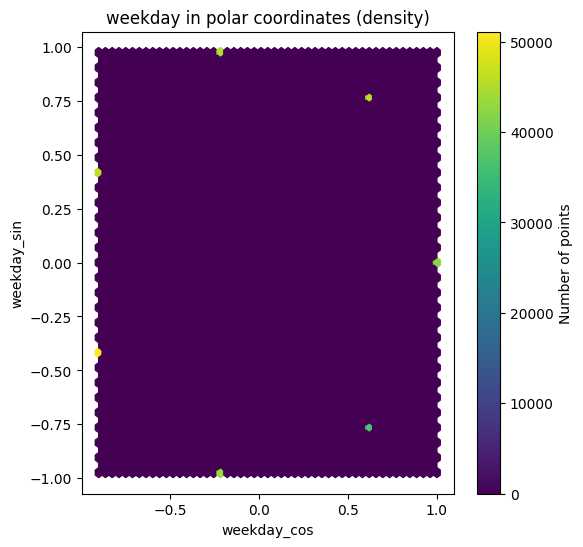

In [35]:
pairs = [('day_cos', 'day_sin'), ('hour_cos', 'hour_sin'), ('month_cos', 'month_sin'), ('weekday_cos', 'weekday_sin')]

for x, y in pairs:
    plt.figure(figsize=(6,6))
    plt.hexbin(df_caract[x], df_caract[y], gridsize=50, cmap='viridis')
    plt.colorbar(label='Number of points')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x.split('_')[0]} in polar coordinates (density)")
    plt.show()

In [36]:
df_usagers = pandas.read_csv("df_usagers_clean.csv")
df_caract_with_target = df_usagers[['Num_Acc', 'grav_bin']].merge(
    df_caract,      
    on='Num_Acc',
    how='left'
)

In [37]:
df_caract_with_target.isna().sum()

Num_Acc            0
grav_bin           0
lum            42192
agg            42192
int            42192
atm            42192
col            42192
lat            42192
long           42192
day_sin        42192
day_cos        42192
month_sin      42192
month_cos      42192
weekday_sin    42192
weekday_cos    42192
hour_sin       42192
hour_cos       42192
is_weekend     42192
dtype: int64

In [38]:
df_caract_with_target = df_caract_with_target.dropna()

In [39]:
df_caract_analyse = df_caract_with_target.copy() 

In [40]:
df_caract_analyse['day_of_year'] = np.arctan2(df_caract_analyse['day_sin'], df_caract_analyse['day_cos'])
df_caract_analyse['day_of_year'] = (df_caract_analyse['day_of_year'] % (2*np.pi)) * 365 / (2*np.pi)

df_caract_analyse['hour'] = np.arctan2(df_caract_analyse['hour_sin'], df_caract_analyse['hour_cos'])
df_caract_analyse['hour'] = (df_caract_analyse['hour'] % (2*np.pi)) * 24 / (2*np.pi)

df_caract_analyse['month'] = np.arctan2(df_caract_analyse['month_sin'], df_caract_analyse['month_cos'])
df_caract_analyse['month'] = (df_caract_analyse['month'] % (2*np.pi)) * 12 / (2*np.pi)

df_caract_analyse['weekday'] = np.arctan2(df_caract_analyse['weekday_sin'], df_caract_analyse['weekday_cos'])
df_caract_analyse['weekday'] = (df_caract_analyse['weekday'] % (2*np.pi)) * 7 / (2*np.pi)     


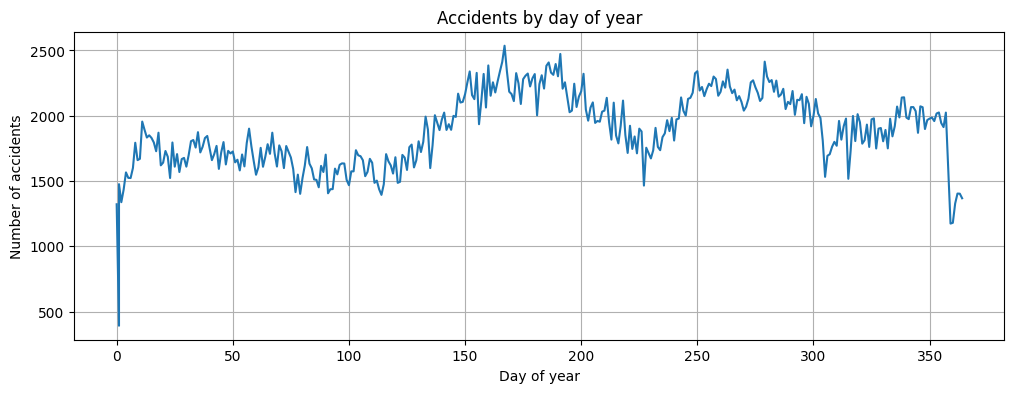

In [41]:
daily_counts = df_caract_analyse.groupby('day_of_year')['grav_bin'].count()
plt.figure(figsize=(12,4))
plt.plot(daily_counts.index, daily_counts.values)
plt.xlabel("Day of year")
plt.ylabel("Number of accidents")
plt.title("Accidents by day of year")
plt.grid(True)
plt.show()

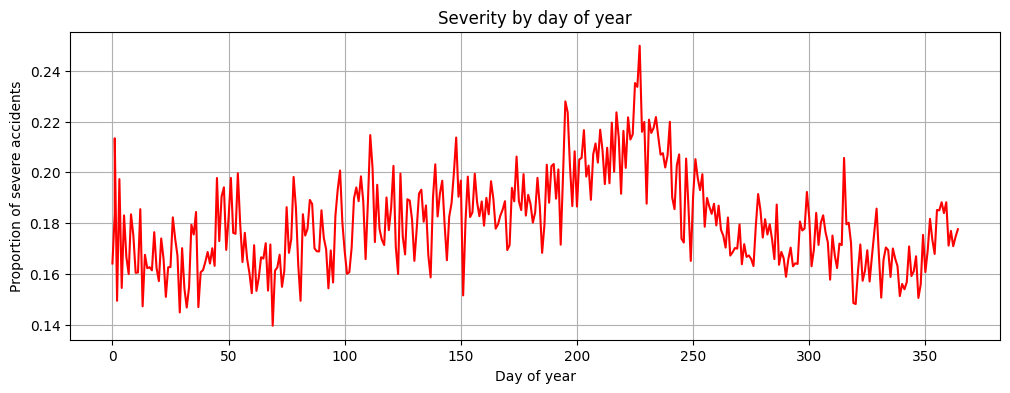

In [42]:
daily_severe = df_caract_analyse.groupby('day_of_year')['grav_bin'].mean()
plt.figure(figsize=(12,4))
plt.plot(daily_severe.index, daily_severe.values, color='red')
plt.xlabel("Day of year")
plt.ylabel("Proportion of severe accidents")
plt.title("Severity by day of year")
plt.grid(True)
plt.show()

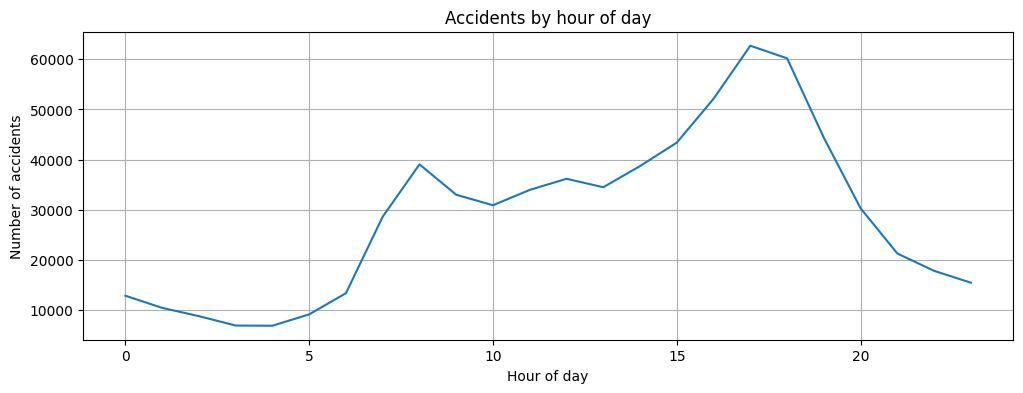

In [43]:
hourly_counts = df_caract_analyse.groupby('hour')['grav_bin'].count()
plt.figure(figsize=(12,4))
plt.plot(hourly_counts.index, hourly_counts.values)
plt.xlabel("Hour of day")
plt.ylabel("Number of accidents")
plt.title("Accidents by hour of day")
plt.grid(True)
plt.show()

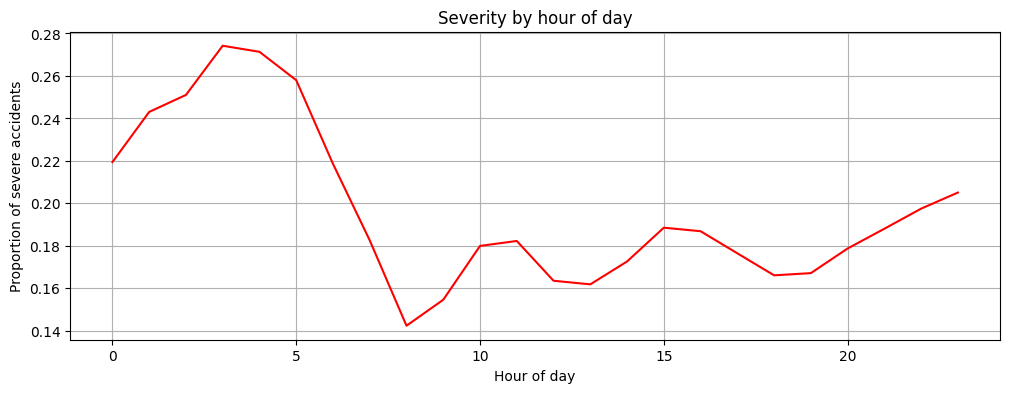

In [44]:
hourly_severe = df_caract_analyse.groupby('hour')['grav_bin'].mean()
plt.figure(figsize=(12,4))
plt.plot(hourly_severe.index, hourly_severe.values, color='red')
plt.xlabel("Hour of day")
plt.ylabel("Proportion of severe accidents")
plt.title("Severity by hour of day")
plt.grid(True)
plt.show()

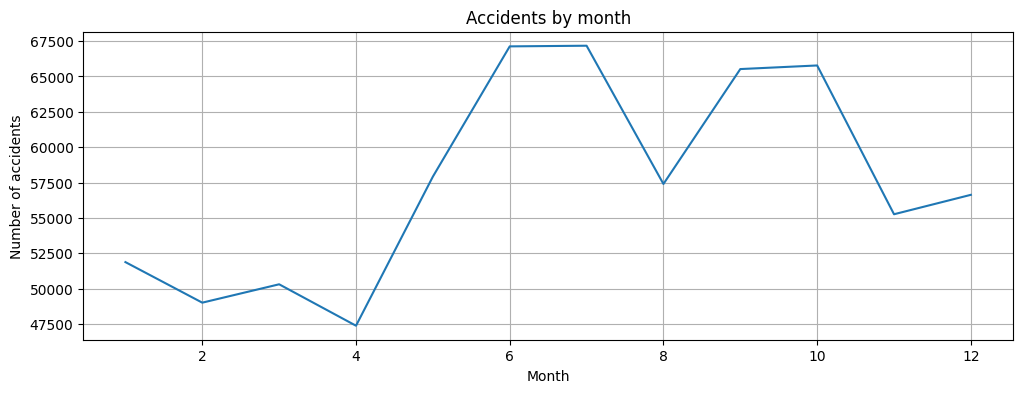

In [45]:
monthly_counts = df_caract_analyse.groupby('month')['grav_bin'].count()
plt.figure(figsize=(12,4))
plt.plot(monthly_counts.index, monthly_counts.values)
plt.xlabel("Month")
plt.ylabel("Number of accidents")
plt.title("Accidents by month")
plt.grid(True)
plt.show()

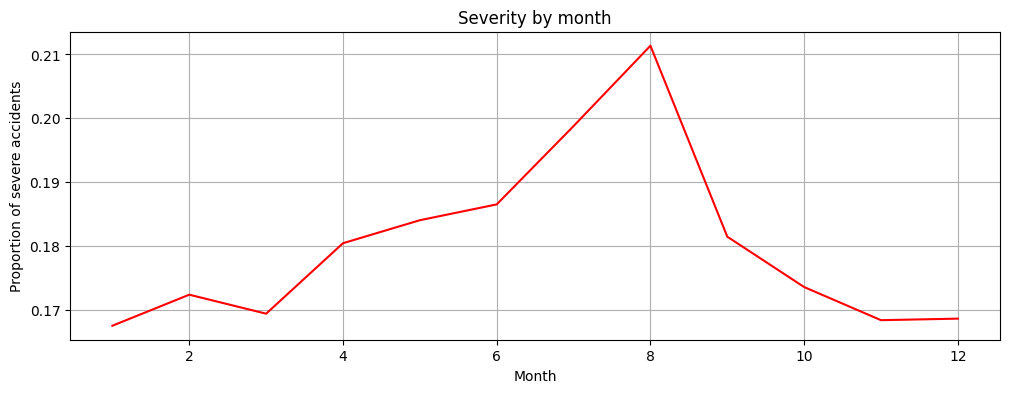

In [46]:
monthly_severe = df_caract_analyse.groupby('month')['grav_bin'].mean()
plt.figure(figsize=(12,4))
plt.plot(monthly_severe.index, monthly_severe.values, color='red')
plt.xlabel("Month")
plt.ylabel("Proportion of severe accidents")
plt.title("Severity by month")
plt.grid(True)
plt.show()

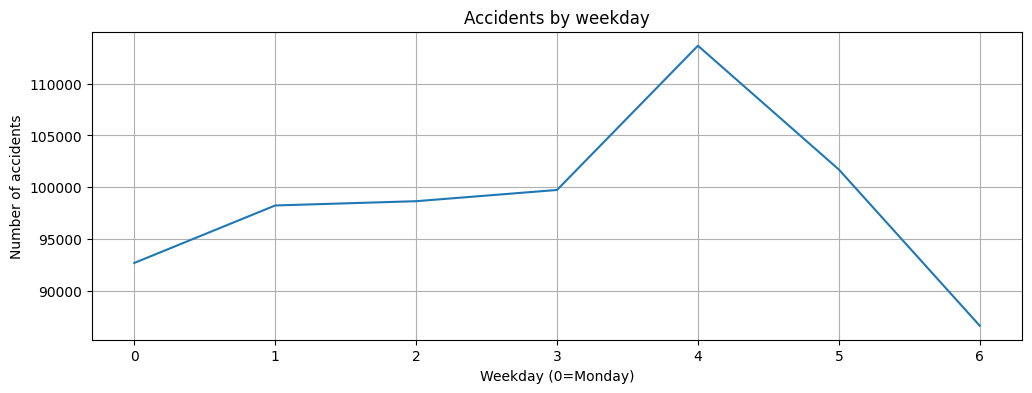

In [47]:
weekly_counts = df_caract_analyse.groupby('weekday')['grav_bin'].count()
plt.figure(figsize=(12,4))
plt.plot(weekly_counts.index, weekly_counts.values)
plt.xlabel("Weekday (0=Monday)")
plt.ylabel("Number of accidents")
plt.title("Accidents by weekday")
plt.grid(True)
plt.show()

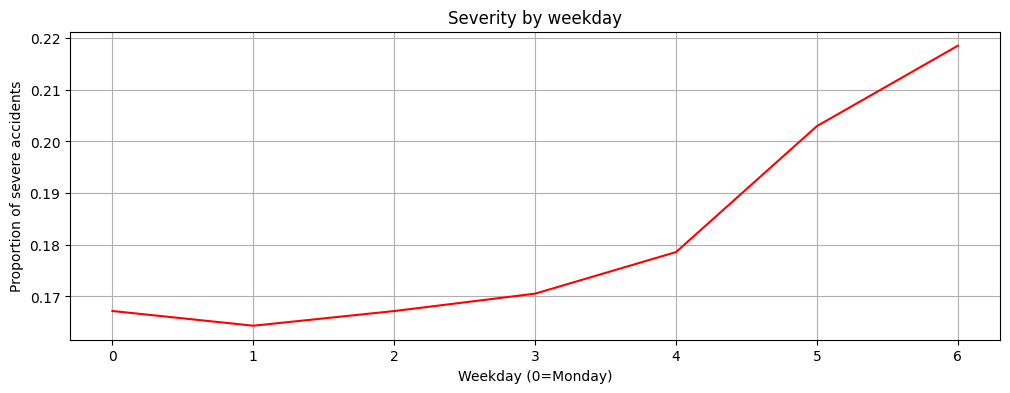

In [48]:
weekly_severe = df_caract_analyse.groupby('weekday')['grav_bin'].mean()
plt.figure(figsize=(12,4))
plt.plot(weekly_severe.index, weekly_severe.values, color='red')
plt.xlabel("Weekday (0=Monday)")
plt.ylabel("Proportion of severe accidents")
plt.title("Severity by weekday")
plt.grid(True)
plt.show()

In [49]:
mapping = {1 : "Plein jour" , 
2 : "Crépuscule ou aube"  ,
3 : "Nuit sans éclairage public"  ,
4 : "Nuit avec éclairage public non allumé"  ,
5 : "Nuit avec éclairage public allumé" }
df_caract_analyse["lum"] = df_caract_analyse["lum"].replace(mapping)

mapping = {1 : "Hors agglomération",
2 : "En agglomération"}
df_caract_analyse["agg"] = df_caract_analyse["agg"].replace(mapping)

mapping = {1 : "Hors intersection" ,
2 : "Intersection en X",
3 : "Intersection en T",  
4 : "Intersection en Y", 
5 : "Intersection à plus de 4 branches", 
6 : "Giratoire" , 
7 : "Place"  ,
8 : "Passage à niveau",  
9 : "Autre intersection"  
}
df_caract_analyse["int"] = df_caract_analyse["int"].replace(mapping)

mapping = {
1 : "Normale"  ,
2 : "Pluie légère"  ,  
3 : "Pluie forte"  ,
4 : "Neige - grêle " , 
5 : "Brouillard - fumée ", 
6 : "Vent fort - tempête",  
7 : "Temps éblouissant",  
8 : "Temps couvert",  
9 : "Autre"}
df_caract_analyse["atm"] = df_caract_analyse["atm"].replace(mapping)

mapping = {
1 : "Deux véhicules - frontale",  
2 : "Deux véhicules – par l’arrière",
3 : "Deux véhicules – par le coté" ,
4 : "Trois véhicules et plus – en chaîne",  
5 : "Trois véhicules et plus - collisions multiples" ,
6 : "Autre collision" ,
7 : "Sans collision" }
df_caract_analyse["col"] = df_caract_analyse["col"].replace(mapping)

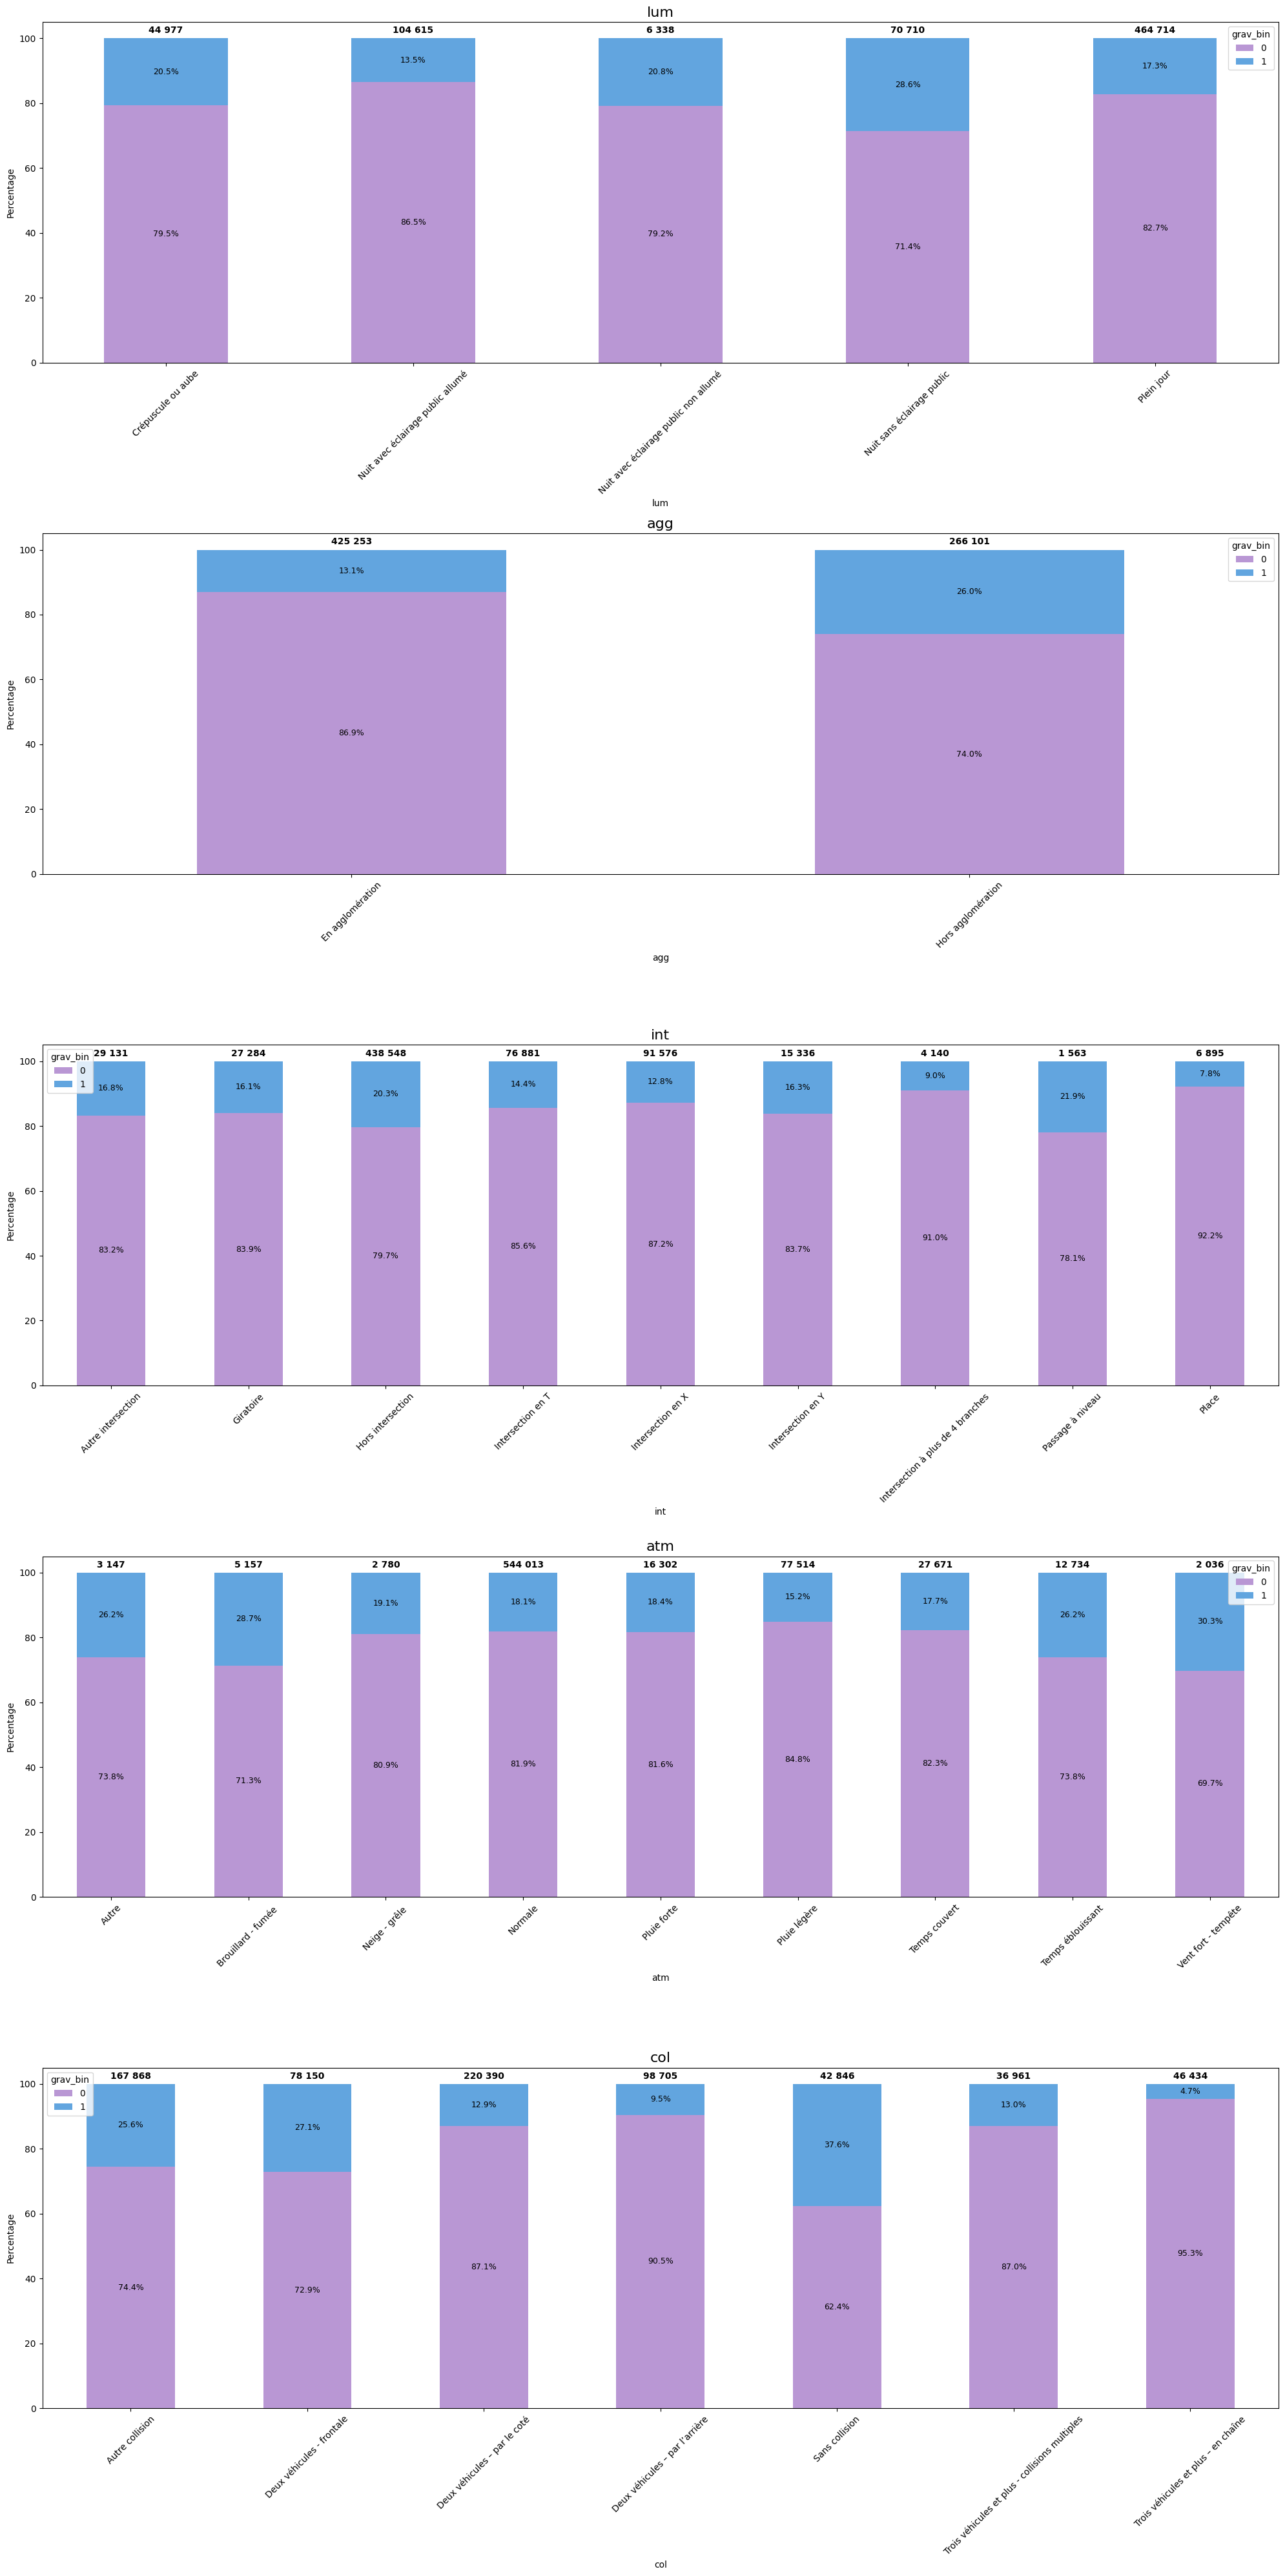

In [50]:
fig, ax = plt.subplots(len(categorical_features), 1, figsize=(20, 6*len(categorical_features) + 10))

df_caract_analyse = df_caract_analyse.reset_index(drop=True)

for i, feature in enumerate(categorical_features):
    ct = pandas.crosstab(
        df_caract_analyse[feature],
        df_caract_analyse[target],
        normalize="index"
    ) * 100

    counts = df_caract_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,  # slightly above 100%
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

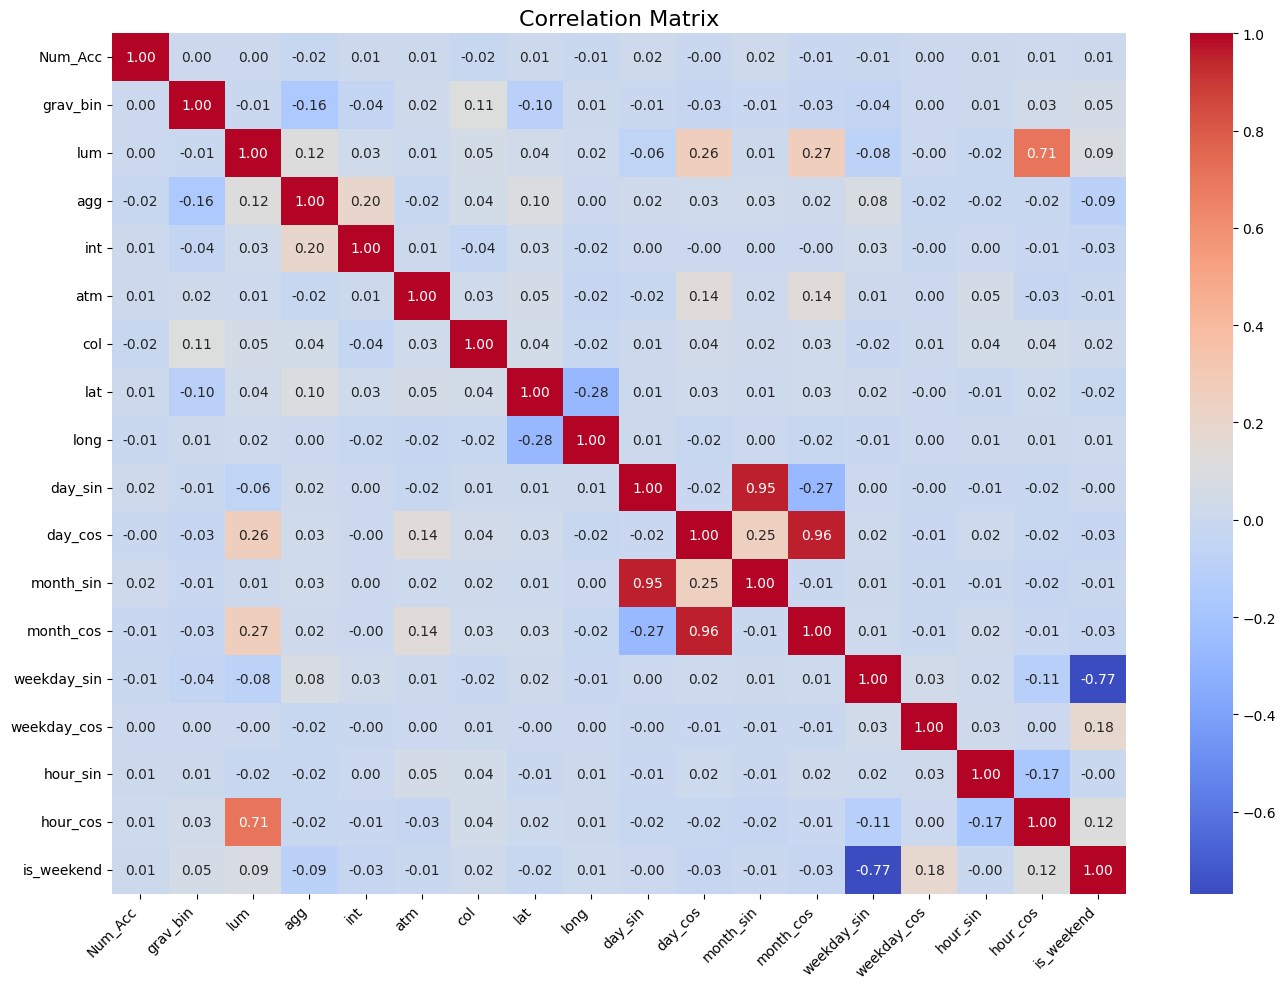

In [51]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df_caract_with_target.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [52]:
X = df_caract_with_target[categorical_features + numerical_features+ binary_features]
y = df_caract_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bin_cat", "passthrough", binary_features)
    ]
)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

for name, pipe in pipelines.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=5) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))


 Logistic Regression
Precision: 0.514461247637051
Recall: 0.05442129259318509
F1: 0.09843032297732286
Accuracy: 0.8197196442486933
              precision    recall  f1-score   support

           0       0.83      0.99      0.90    453067
           1       0.51      0.05      0.10    100016

    accuracy                           0.82    553083
   macro avg       0.67      0.52      0.50    553083
weighted avg       0.77      0.82      0.75    553083


 Decision Tree
Precision: 0.31323519875494454
Recall: 0.24148136298192288
F1: 0.2727175207908718
Accuracy: 0.7670928233194656
              precision    recall  f1-score   support

           0       0.84      0.88      0.86    453067
           1       0.31      0.24      0.27    100016

    accuracy                           0.77    553083
   macro avg       0.58      0.56      0.57    553083
weighted avg       0.75      0.77      0.75    553083


 Gradient Boosting
Precision: 0.5548774806671014
Recall: 0.1190909454487282
F1: 0.1960

In [54]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = .2)
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val) # un label prédit pour chaque exemple de X_train
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="binary")
    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_val, y_pred))


 Logistic Regression
Precision: 0.5092548647365923
Recall: 0.053644635536446356
F1: 0.09706454385092043
Accuracy: 0.8234261403803769
              precision    recall  f1-score   support

           0       0.83      0.99      0.90     90615
           1       0.51      0.05      0.10     20002

    accuracy                           0.82    110617
   macro avg       0.67      0.52      0.50    110617
weighted avg       0.77      0.82      0.75    110617


 Decision Tree
Precision: 0.9405226209048362
Recall: 0.48225177482251774
F1: 0.6375834490052218
Accuracy: 0.8234261403803769
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     90615
           1       0.94      0.48      0.64     20002

    accuracy                           0.90    110617
   macro avg       0.92      0.74      0.79    110617
weighted avg       0.90      0.90      0.89    110617


 Gradient Boosting
Precision: 0.5605839416058395
Recall: 0.1151884811518848
F1: 0.191

AUC of Logistic Regression: 0.724
AUC of Decision Tree: 0.581
AUC of Gradient Boosting: 0.764


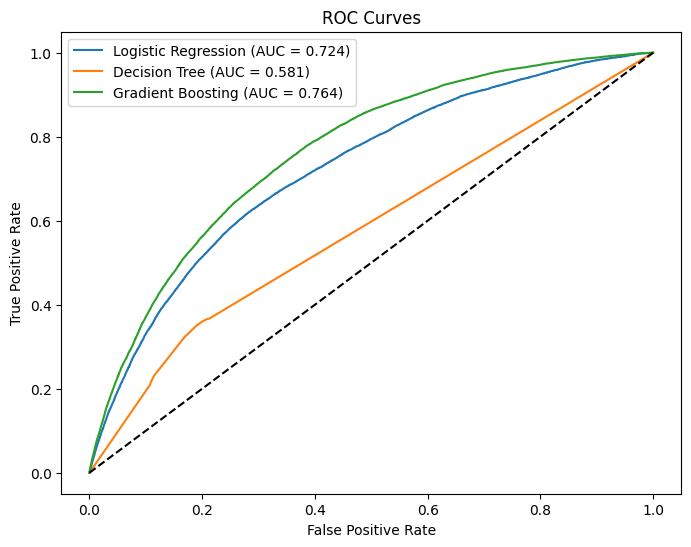

In [55]:
plt.figure(figsize=(8,6))
lst_auc = []

for name, pipe in pipelines.items(): 
    if hasattr(pipe["model"], "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:,1]
    elif hasattr(pipe["model"], "decision_function"):
        y_score = pipe.decision_function(X_test)
    else:
        # fallback: just use predictions (not ideal for ROC, but works)
        y_score = model.predict(X_test)
        print(f"Warning: {name} does not have predict_proba or decision_function, using predict()")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = auc(fpr, tpr)
    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")
    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

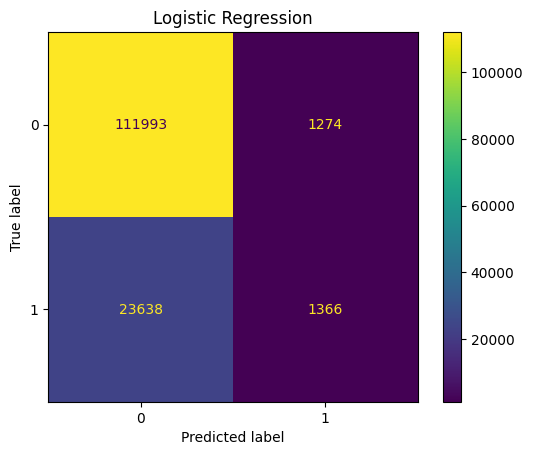

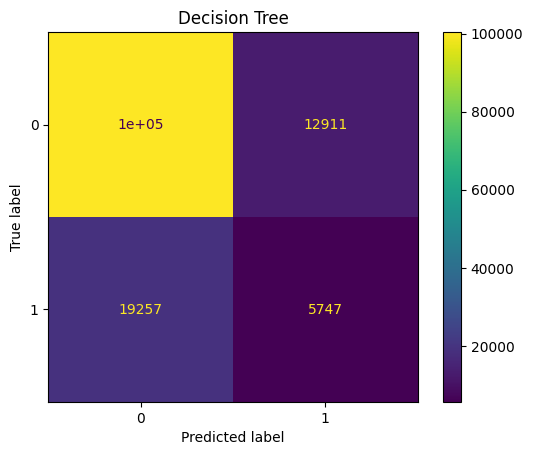

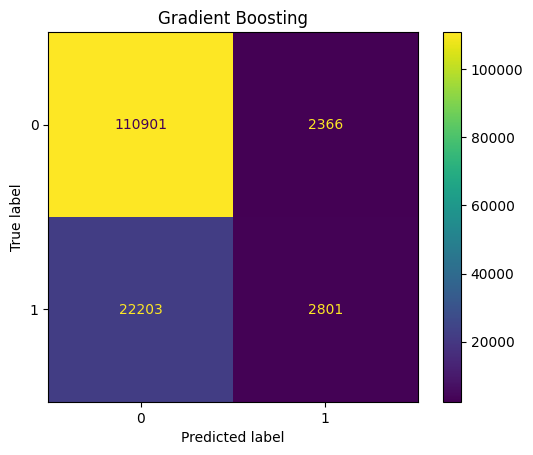

In [56]:
for name, model in pipelines.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()

In [57]:
# Finally we are going to save the dataset cleaned
df_caract.to_csv("df_caract_clean.csv", index=False)

In [58]:
df_caract = pandas.read_csv("df_caract_clean.csv")

In [59]:
print("All columns:", df_caract.columns)
print("Features:", features)

All columns: Index(['Num_Acc', 'lum', 'agg', 'int', 'atm', 'col', 'lat', 'long', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos',
       'hour_sin', 'hour_cos', 'is_weekend'],
      dtype='str')
Features: ['lum', 'agg', 'int', 'atm', 'col', 'is_weekend', 'lat', 'long', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'hour_sin', 'hour_cos']
